## PEAK HOUR AND PAYMENT METHOD VARIANCE OVER TIME
### What is the single busiest hour of the day? 
### How many transactions occur during peak vs. off-peak? 
### Which payment method is most popular overall? 
### Do customer payment preferences shift throughout the day? 
### What are the optimal staffing levels by hour? 
### When can system maintenance occur with zero transaction impact? 
### Do any payment systems bottleneck during peak hours

### LIBRARIES AND DATA

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('supermarket_sales.csv')

### STEP 1 || TIME STRING FORMAT TO OBJECT CONVERSION

In [11]:
df['Time'] = pd.to_datetime(df['Time'])

print("Column Data Types after Conversion:")
print(df[['Time']].dtypes)

print("\nPreview of Activated Time Data:")
print(df['Time'])

Column Data Types after Conversion:
Time    datetime64[us]
dtype: object

Preview of Activated Time Data:
0     2026-04-06 13:08:00
1     2026-04-06 10:29:00
2     2026-04-06 13:23:00
3     2026-04-06 20:33:00
4     2026-04-06 10:37:00
              ...        
995   2026-04-06 13:46:00
996   2026-04-06 17:16:00
997   2026-04-06 13:22:00
998   2026-04-06 15:33:00
999   2026-04-06 13:28:00
Name: Time, Length: 1000, dtype: datetime64[us]


C:\Users\ranat\AppData\Local\Temp\ipykernel_22096\621167457.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


### STEP 2 || Time Conversion into Hours 

In [12]:
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

df.to_csv('supermarket_sales_with_hour.csv', index=False)

print("Time with new 'Hour' column:")
print(df[['Time', 'Hour']])


Time with new 'Hour' column:
                   Time  Hour
0   2026-04-06 13:08:00    13
1   2026-04-06 10:29:00    10
2   2026-04-06 13:23:00    13
3   2026-04-06 20:33:00    20
4   2026-04-06 10:37:00    10
..                  ...   ...
995 2026-04-06 13:46:00    13
996 2026-04-06 17:16:00    17
997 2026-04-06 13:22:00    13
998 2026-04-06 15:33:00    15
999 2026-04-06 13:28:00    13

[1000 rows x 2 columns]


### STEP 3 || Payment method distribution across each Hour.

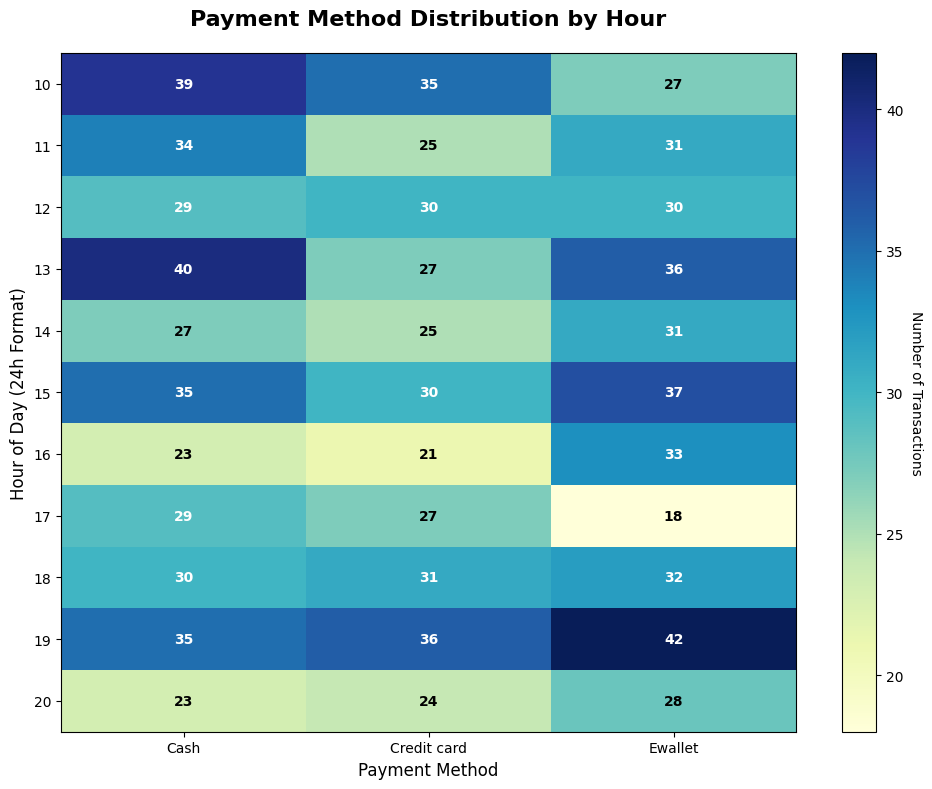

In [13]:
payment_hour_matrix = pd.crosstab(df['Hour'], df['Payment'])

data = payment_hour_matrix.values
hours = payment_hour_matrix.index
payments = payment_hour_matrix.columns

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(data, cmap='YlGnBu', aspect='auto')

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Number of Transactions", rotation=-90, va="bottom")

ax.set_xticks(np.arange(len(payments)))
ax.set_yticks(np.arange(len(hours)))
ax.set_xticklabels(payments)
ax.set_yticklabels(hours)


for i in range(len(hours)):
    for j in range(len(payments)):
        color = "white" if data[i, j] > (data.max() / 1.5) else "black"
        ax.text(j, i, data[i, j], ha="center", va="center", color=color, fontweight='bold')


ax.set_title("Payment Method Distribution by Hour", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Payment Method", fontsize=12)
ax.set_ylabel("Hour of Day (24h Format)", fontsize=12)

plt.tight_layout()
plt.savefig('payment_hour_heatmap_matplotlib.png', dpi=300)

### Step 4 || Chronologically Sorted Transactions

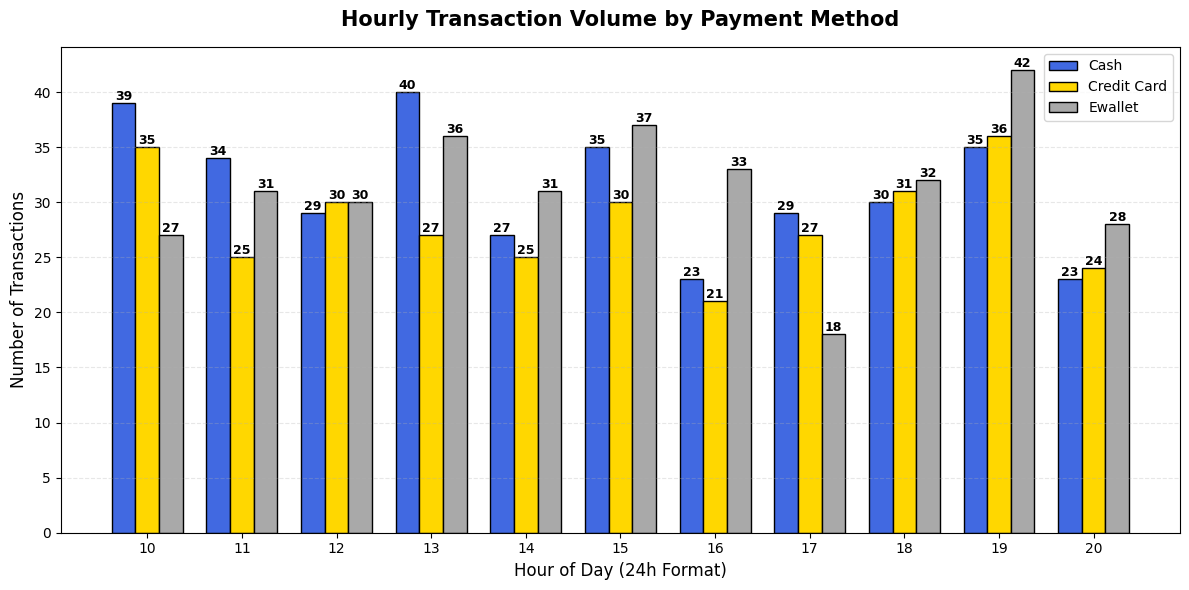

In [14]:
matrix_data_step4 = pd.read_csv('supermarket_sales_with_hour.csv')

raw_pivot_step4 = pd.crosstab(matrix_data_step4['Hour'], matrix_data_step4['Payment'])

chronological_payment_matrix = raw_pivot_step4.sort_index(ascending=True)

hours_axis = chronological_payment_matrix.index
x_pos = np.arange(len(hours_axis))
bar_width = 0.25

fig, ax4 = plt.subplots(figsize=(12, 6))

bars1 = ax4.bar(x_pos - bar_width, chronological_payment_matrix['Cash'], 
        width=bar_width, label='Cash', color='royalblue', edgecolor='black')

bars2 = ax4.bar(x_pos, chronological_payment_matrix['Credit card'], 
        width=bar_width, label='Credit Card', color='gold', edgecolor='black')

bars3 = ax4.bar(x_pos + bar_width, chronological_payment_matrix['Ewallet'], 
        width=bar_width, label='Ewallet', color='darkgray', edgecolor='black')

ax4.bar_label(bars1, fontsize=9, fontweight='bold')
ax4.bar_label(bars2, fontsize=9, fontweight='bold')
ax4.bar_label(bars3, fontsize=9, fontweight='bold')

ax4.set_title('Hourly Transaction Volume by Payment Method', fontsize=15, fontweight='bold', pad=15)
ax4.set_xlabel('Hour of Day (24h Format)', fontsize=12)
ax4.set_ylabel('Number of Transactions', fontsize=12)

ax4.set_xticks(x_pos)
ax4.set_xticklabels(hours_axis)

ax4.grid(axis='y', linestyle='--', alpha=0.3)

ax4.legend(frameon=True, loc='upper right')

plt.tight_layout()

### Step 5 || how payment preferences shift throughout the day.

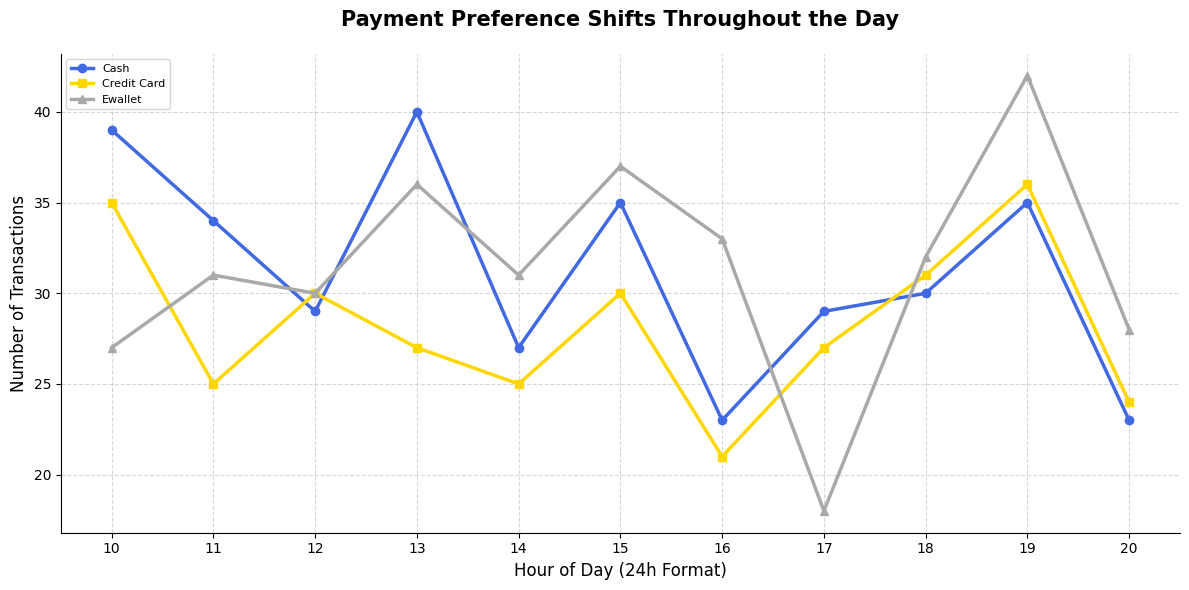

In [15]:
df_step5 = pd.read_csv('supermarket_sales_with_hour.csv')

line_matrix = pd.crosstab(df_step5['Hour'], df_step5['Payment']).sort_index()

fig, ax5 = plt.subplots(figsize=(12, 6))

ax5.plot(line_matrix.index, line_matrix['Cash'], 
         label='Cash', color='royalblue', linewidth=2.5, marker='o')

ax5.plot(line_matrix.index, line_matrix['Credit card'], 
         label='Credit Card', color='gold', linewidth=2.5, marker='s')

ax5.plot(line_matrix.index, line_matrix['Ewallet'], 
         label='Ewallet', color='darkgray', linewidth=2.5, marker='^')

ax5.set_title('Payment Preference Shifts Throughout the Day', fontsize=15, fontweight='bold', pad=20)
ax5.set_xlabel('Hour of Day (24h Format)', fontsize=12)
ax5.set_ylabel('Number of Transactions', fontsize=12)

ax5.set_xticks(line_matrix.index)

ax5.grid(True, linestyle='--', alpha=0.5) 
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)


ax5.legend(loc='upper left', fontsize=8)

plt.tight_layout()

### Step 6 || Key Takeaways and Business Insights

In [16]:
total_transactions_per_hour = line_matrix.sum(axis=1)

peak_hour_val = total_transactions_per_hour.idxmax()
peak_traffic_count = total_transactions_per_hour.max()

trough_hour_val = total_transactions_per_hour.idxmin()
trough_traffic_count = total_transactions_per_hour.min()

digital_only_matrix = line_matrix[['Credit card', 'Ewallet']]
digital_stress_hour = digital_only_matrix.sum(axis=1).idxmax()
leading_digital_method = line_matrix.loc[digital_stress_hour, ['Credit card', 'Ewallet']].idxmax()

print(f"{'='*20} STEP 6: BUSINESS INSIGHTS {'='*20}")
print(f"1. PEAK PATTERN:   The busiest hour is {peak_hour_val}:00 with {peak_traffic_count} transactions.")
print(f"2. TROUGH PATTERN: The quietest hour is {trough_hour_val}:00 with {trough_traffic_count} transactions.")
print(f"3. PAYMENT SHIFT:  At the {peak_hour_val}:00 peak, {leading_digital_method} is the dominant digital method.")
print(f"4. SYSTEM STRESS:  Server load will be HIGHEST at {digital_stress_hour}:00 due to digital payment volume.")
print(f"{'='*53}")

==================== STEP 6: BUSINESS INSIGHTS ====================
1. PEAK PATTERN:   The busiest hour is 19:00 with 113 transactions.
2. TROUGH PATTERN: The quietest hour is 17:00 with 74 transactions.
3. PAYMENT SHIFT:  At the 19:00 peak, Ewallet is the dominant digital method.
4. SYSTEM STRESS:  Server load will be HIGHEST at 19:00 due to digital payment volume.
